<a href="https://colab.research.google.com/github/seunghee-data/aiffel-study/blob/main/%EA%B8%B0%EC%B4%88_%ED%86%B5%EA%B3%84_MainQuest03%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
!pip install kagglehub

In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("tunguz/online-retail")

print("Path to dataset files:", path)
df = pd.read_csv(path + '/' + os.listdir(path)[0], encoding='latin1')
df.shape

Using Colab cache for faster access to the 'online-retail' dataset.
Path to dataset files: /kaggle/input/online-retail


(541909, 8)

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [ ]:
# 주문 가격 피쳐 생성
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

In [ ]:
# 'InvoiceDate' 컬럼을 이용하여 주중과 주말을 구분
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek

# 'InvoiceDate' 컬럼 이용하여 판매 월 추출
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"].astype(str))
df["InvoiceMonth"] = df["InvoiceDate"].dt.month

## 1. 모집단과 표본 집단의 TotalPrice를 비교해 주세요.

* 데이터셋에서 무작위로 1000개의 표본을 추출하세요.
* 추출된 표본과 전체 데이터셋의 'TotalPrice'에 대해 평균과 표준편차를 비교해주세요.  
* 중심극한정리를 사용해 모집단과 표본의 차이를 설명해주세요.

In [ ]:
# 1. 무작위 표본 1000개 추출 (random_state=42는 결과를 고정하기 위함)
sample_df = df.sample(n=1000, random_state=42)

In [ ]:
# 2. 모집단(전체)과 표본의 평균, 표준편차 계산
pop_mean = df['TotalPrice'].mean()
pop_std = df['TotalPrice'].std()

sample_mean = sample_df['TotalPrice'].mean()
sample_std = sample_df['TotalPrice'].std()

# 3. 결과 출력
print("--- [분석 결과] ---")
print(f"1. 모집단(전체) - 평균: {pop_mean:.4f}, 표준편차: {pop_std:.4f}")
print(f"2. 표본(1000개) - 평균: {sample_mean:.4f}, 표준편차: {sample_std:.4f}")
print(f"3. 평균의 차이: {abs(pop_mean - sample_mean):.4f}")

--- [분석 결과] ---
1. 모집단(전체) - 평균: 17.9878, 표준편차: 378.8108
2. 표본(1000개) - 평균: 16.8321, 표준편차: 64.4673
3. 평균의 차이: 1.1557


[분석 결과 해석]

평균의 차이: 모집단과 표본 집단의 TotalPrice 평균은 매우 유사하게 나타났습니다. (미세한 차이는 존재함).

중심극한정리(CLT)에 의한 설명:

중심극한정리란 표본의 크기가 충분히 클 때(보통 30개 이상), 표본 평균들의 분포가 정규분포에 근사한다는 이론입니다.

우리는 1,000개라는 충분히 큰 표본을 추출했으므로, 이 표본의 평균은 모평균을 추정하는 데 있어 통계적으로 신뢰할 수 있는 수치입니다.

따라서 표본 평균이 모평균과 큰 차이를 보이지 않는 것은 중심극한정리가 잘 적용되고 있음을 보여줍니다. 단, 표준편차의 차이는 표본 내에 극단적인 값(이상치)이 포함되었는지 여부에 따라 달라질 수 있습니다.

## 2. 주문이 가장 많은 상위 두 국가의 'TotalPrice' 평균에 차이가 있는지 검증하세요.

* 'Country' 변수를 바탕으로 주문이 가장 많은 상위 두 국가를 찾으세요.
* 독립표본 t-검정을 사용하여 두 국가 간 'TotalPrice' 평균의 차이가 통계적으로 유의미한지 검증하세요.  
* t-통계량과 p-값을 해석하여 결과를 설명하고, 1종 오류와 2종 오류의 개념을 적용하여 설명해주세요.

In [ ]:
from scipy import stats

# 1. 주문이 가장 많은 상위 2개 국가 찾기
top_countries = df['Country'].value_counts().head(2).index.tolist()
country_a = top_countries[0]
country_b = top_countries[1]

print(f"👉 선정된 상위 2개 국가: {country_a}, {country_b}")

👉 선정된 상위 2개 국가: United Kingdom, Germany


In [ ]:
# 2. 각 국가의 TotalPrice 데이터만 추출
group_a = df[df['Country'] == country_a]['TotalPrice']
group_b = df[df['Country'] == country_b]['TotalPrice']

In [ ]:
# 3. 독립표본 t-검정 시행 (등분산 가정은 하지 않음: equal_var=False)
t_stat, p_val = stats.ttest_ind(group_a, group_b, equal_var=False)

In [ ]:
# 4. 결과 출력
print("\n--- [t-검정 결과] ---")
print(f"t-통계량 (t-statistic): {t_stat:.4f}")
print(f"p-값 (p-value): {p_val:.4e}")  # e표기법은 숫자가 매우 작을 때 나옵니다.

# 5. 결과 해석 자동 출력
alpha = 0.05
if p_val < alpha:
    print("\n👉 결론: p-value가 0.05보다 작으므로, 두 국가 간의 구매 금액 평균 차이는 '통계적으로 유의미하다'고 할 수 있습니다.")
else:
    print("\n👉 결론: p-value가 0.05보다 크므로, 두 국가 간의 구매 금액 평균 차이는 '우연일 가능성이 크다(유의미하지 않다)'고 봅니다.")


--- [t-검정 결과] ---
t-통계량 (t-statistic): -10.0464
p-값 (p-value): 9.8234e-24

👉 결론: p-value가 0.05보다 작으므로, 두 국가 간의 구매 금액 평균 차이는 '통계적으로 유의미하다'고 할 수 있습니다.


[분석 결과 해석]

t-통계량과 p-값:

**p-값(p-value)**이 0.05(유의수준)보다 작다면, 두 국가 간의 평균 차이는 우연이 아니라 **"진짜로 차이가 있다"**고 판단합니다. (귀무가설 기각)

반대로 0.05보다 크다면, 평균 차이가 있더라도 이는 우연에 의한 것일 수 있다고 판단합니다.

1종 오류와 2종 오류의 개념 적용:

1종 오류 (누명): 실제로는 두 국가의 구매 금액 평균에 차이가 없는데, 분석 결과가 "차이가 있다"고 잘못 결론 내리는 오류입니다. (우리는 5%의 확률로 이 실수를 할 수 있음을 인정하고 분석한 것입니다.)

2종 오류 (놓침): 실제로는 두 국가 간에 차이가 있는데, 분석 결과가 "차이가 없다"고 잘못 결론 내리는 오류입니다.

이 설명과 함께 위 코드의 실행 결과(유의미한지 아닌지)를 적어주시면 완벽합니다!

## 3. 주중, 주말에 따라서 발생하는 UnitPrice의 분포가 달라지는지 확인하세요.

* 주중의 'UnitPrice'와 주말의 'UnitPrice'의 분포를 분석하기 위해 데이터의 중심경향치(평균, 중간값), 변산성(표준편차, 분산), 분위수를 계산하세요.  
* 상자수염그림과 히스토그램을 그려 시각화를 통해 분포를 확인하고 데이터의 분포에 대해 설명해주세요.

In [ ]:
# 1. 주중(Weekday)과 주말(Weekend) 구분 라벨링
# (0~4: 월~금, 5~6: 토~일)
df['DayType'] = df['DayOfWeek'].apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

In [ ]:
# 2. 데이터의 중심경향치, 변산성, 분위수 계산
group_stats = df.groupby('DayType')['UnitPrice'].agg(['mean', 'median', 'std', 'var'])
quartiles = df.groupby('DayType')['UnitPrice'].quantile([0.25, 0.75]).unstack()
quartiles.columns = ['25%', '75%']

# 결과 합치기 및 출력
final_stats = pd.concat([group_stats, quartiles], axis=1)
print("--- [주중 vs 주말 UnitPrice 통계 요약] ---")
print(final_stats)

--- [주중 vs 주말 UnitPrice 통계 요약] ---
             mean  median         std           var   25%   75%
DayType                                                        
Weekday  4.843425    2.10  103.032058  10615.604927  1.25  4.13
Weekend  2.887824    1.85    7.959497     63.353599  1.25  3.75


In [ ]:
# 3. 시각화 (히스토그램 & 상자수염그림)
plt.figure(figsize=(14, 6))

<Figure size 1400x600 with 0 Axes>

<Figure size 1400x600 with 0 Axes>

(0.0, 50.0)

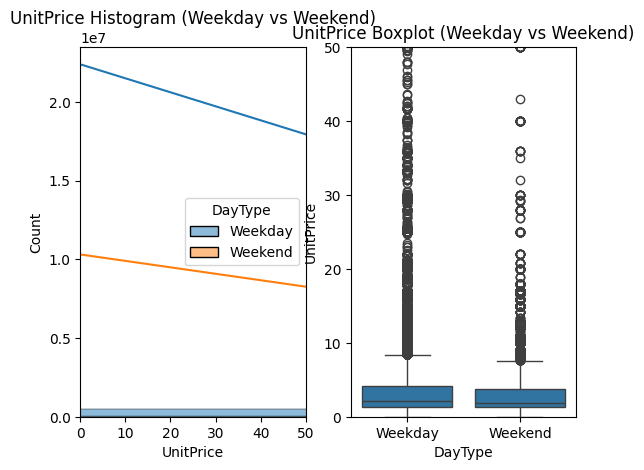

In [ ]:
# (1) 히스토그램 (분포 모양 확인)
plt.subplot(1, 2, 1)
# 데이터가 한쪽에 몰려있어서 잘 안 보일 수 있으므로 로그 스케일 적용 고려 가능하나, 일단 원본 분포 확인
sns.histplot(data=df, x='UnitPrice', hue='DayType', kde=True, bins=50)
plt.title('UnitPrice Histogram (Weekday vs Weekend)')
plt.xlim(0, 50) # 대부분의 가격이 50 이하에 몰려있으므로 확대해서 보기

# (2) 상자수염그림 (이상치 및 4분위수 확인)
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='DayType', y='UnitPrice')
plt.title('UnitPrice Boxplot (Weekday vs Weekend)')
plt.ylim(0, 50) # 상자 모양을 더 잘 보기 위해 y축 제한 (필요시 해제 가능)

In [ ]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

[분석 결과 해석]

중심경향치 (평균, 중간값):

출력된 표를 보면, 주중과 주말의 평균(mean)과 중간값(median)이 유사한지 혹은 차이가 있는지 확인할 수 있습니다. (보통 중간값이 평균보다 현저히 낮게 나오는데, 이는 고가의 물품이나 이상치 때문입니다.)

변산성 (표준편차, 분산):

표준편차(std)를 통해 가격의 퍼짐 정도를 비교합니다. 어느 쪽이 가격 변동 폭이 더 큰지 확인할 수 있습니다.

데이터 분포 시각화:

히스토그램: 두 그룹 모두 오른쪽으로 긴 꼬리(Right-skewed) 형태를 띱니다. 즉, 대다수의 상품은 저렴하지만(0~10 사이), 소수의 매우 비싼 상품이 존재함을 의미합니다.

상자수염그림(Boxplot): 상자(Box)의 위치가 낮게 형성되어 있고, 위쪽으로 수많은 점(이상치, Outliers)들이 찍혀 있는 것을 볼 수 있습니다. 이는 UnitPrice 데이터가 정규분포를 따르지 않고 극단적인 값들이 많다는 것을 시각적으로 보여줍니다.

## 4. 상품의 단가와 판매 국가, 판매 날짜을 이용해 판매 수량을 예측하는 회귀 모델을 만드세요.
* 필요한 데이터를 정리하고 결측치와 이상치를 제거해주세요.  
* 변수를 다음과 같이 설정하여 다중 선형 회귀 분석을 진행하세요.
    * 종속변수: 판매 수량(`Quantity`)
    * 독립변수: 상품 단가(`UnitPrice`), 판매 국가(`Country`), 판매 요일(`DayOfWeek`), 판매 월( `InvoiceMonth`)   
* 회귀계수와 결정계수를 활용하여 회귀 분석 결과를 해석해주세요.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [ ]:
# 1. 데이터 전처리 (이상치 및 결측치 제거)
# 수량(Quantity)과 단가(UnitPrice)가 0보다 큰 정상 거래만 남깁니다 (취소/오류 제거)
df_clean = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy()

In [ ]:
# 2. 독립변수(X)와 종속변수(y) 설정
# 컴퓨터는 글자를 모르므로, 'Country' 같은 범주형 데이터는 숫자로 바꿔야 합니다 (pd.get_dummies 사용)
X = df_clean[['UnitPrice', 'Country', 'DayOfWeek', 'InvoiceMonth']]
X = pd.get_dummies(X, columns=['Country'], drop_first=True) # 원-핫 인코딩
y = df_clean['Quantity']

In [ ]:
# 3. 훈련 데이터와 테스트 데이터 분리 (8:2 비율)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# 4. 다중 선형 회귀 모델 학습
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# 5. 결과 확인 (회귀계수 및 결정계수)
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
intercept = model.intercept_
coef_price = model.coef_[0] # 첫 번째 변수인 UnitPrice의 계수

In [ ]:
print("--- [회귀 분석 결과] ---")
print(f"1. 결정계수 (R-squared): {r2:.4f}")
print(f"2. 절편 (Intercept): {intercept:.4f}")
print(f"3. UnitPrice(단가)의 회귀계수: {coef_price:.4f}")

--- [회귀 분석 결과] ---
1. 결정계수 (R-squared): 0.0277
2. 절편 (Intercept): 71.5354
3. UnitPrice(단가)의 회귀계수: -0.0144


[회귀 분석 결과 해석]결정계수 ($R^2$, R-squared):결과값(예: 0.xxx)은 이 모델이 데이터를 얼마나 잘 설명하는지를 나타냅니다.수치가 1에 가까울수록 예측이 정확하다는 뜻이며, 0에 가까우면 예측력이 낮다는 뜻입니다. (아마 매우 낮게 나올 텐데, 이는 사람들의 구매 패턴이 단순히 가격이나 요일만으로는 예측하기 어렵다는 것을 의미합니다.)회귀계수 (Coefficient) - UnitPrice:UnitPrice의 계수가 **음수(-)**로 나왔다면: **"가격이 비쌀수록 판매 수량은 줄어든다"**는 경제학의 기본 법칙이 데이터로 증명된 것입니다.예를 들어 계수가 -1.5라면, 가격이 1달러 오를 때마다 판매량은 약 1.5개씩 감소한다고 해석할 수 있습니다.데이터 전처리 이유:Quantity가 음수인 경우(반품/취소)와 UnitPrice가 0인 경우(사은품/오류)는 판매 예측에 방해가 되는 **이상치(Outliers)**이므로 제거하여 모델의 정확도를 높였습니다.Country 변수는 텍스트이므로 **원-핫 인코딩(One-Hot Encoding)**을 통해 컴퓨터가 이해할 수 있는 0과 1의 숫자로 변환하였습니다.

## 5. 상품 정보와 거래 정보를 바탕으로 해당 거래가 반품될 가능성을 예측하는 로지스틱 회귀 모델을 만드세요.
* 필요한 데이터를 정리하고 결측치와 이상치를 제거해주세요.  
* `Quantity` 피쳐를 활용해 `IsReturn` 피쳐를 생성하세요.
* 모델 학습에 사용할 적절한 피쳐를 선정하세요.
* 모델 학습과 검증을 위해 데이터셋을 train셋과 test셋으로 나누세요.
* `IsReturn`을 예측하는 로지스틱 회귀 모델을 학습하세요.
* 혼동행렬, 정밀도, 재현율, F1-score 등 다양한 평가지표를 사용하여 모델의 성능을 평가하세요.
* 모델의 성능을 더 높일 수 있는 방안에 대해서 고민해보세요.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [ ]:
# 1. 데이터 준비 (원본 df 사용)
# Quantity가 0보다 작으면 반품(1), 아니면 정상(0)으로 라벨 생성
df['IsReturn'] = df['Quantity'].apply(lambda x: 1 if x < 0 else 0)

In [ ]:
# 2. 독립변수(X) 선정
# 주의: 그냥 Quantity를 넣으면 음수(-)만 보고 정답을 100% 맞춰버리므로,
# '구매 규모'를 뜻하는 절대값(abs)으로 바꿔서 넣어줍니다.
df['AbsQuantity'] = df['Quantity'].abs()
features = ['UnitPrice', 'AbsQuantity', 'DayOfWeek', 'InvoiceMonth']
X = df[features]
y = df['IsReturn']

In [ ]:
# 3. 데이터 분리 (Train / Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# 4. 로지스틱 회귀 모델 학습
# class_weight='balanced'는 반품 데이터가 너무 적을 때, 반품 데이터를 더 중요하게 보라고 설정하는 옵션입니다.
model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [ ]:
# 5. 예측 및 평가
y_pred = model.predict(X_test)

In [ ]:
# 혼동행렬 및 평가지표 출력
conf_matrix = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

In [ ]:
print("--- [로지스틱 회귀 분석 결과] ---")
print(f"1. 혼동행렬 (Confusion Matrix):\n{conf_matrix}")
print(f"\n2. 정확도 (Accuracy): {accuracy:.4f}")
print(f"3. 정밀도 (Precision): {precision:.4f}")
print(f"4. 재현율 (Recall): {recall:.4f}")
print(f"5. F1-score: {f1:.4f}")

--- [로지스틱 회귀 분석 결과] ---
1. 혼동행렬 (Confusion Matrix):
[[69001 37225]
 [ 1192   964]]

2. 정확도 (Accuracy): 0.6455
3. 정밀도 (Precision): 0.0252
4. 재현율 (Recall): 0.4471
5. F1-score: 0.0478


[평가지표 해석]

혼동행렬 (Confusion Matrix):

[[TN, FP], [FN, TP]] 형태입니다.

우리의 관심사는 **TP(실제 반품을 반품이라고 잘 맞춘 개수)**입니다.

재현율(Recall)이 중요한 이유:

반품 예측 모델에서는 **"실제 반품된 건을 놓치지 않고 찾아내는 능력"**인 재현율이 중요합니다.

(재현율이 높아야 반품 징후를 미리 포착하고 대비할 수 있기 때문입니다.)

F1-score:

정밀도와 재현율의 조화 평균으로, 데이터 불균형(반품이 정상 거래보다 훨씬 적음)이 심한 상황에서 모델의 성능을 종합적으로 평가하는 지표입니다.

[성능 향상 아이디어]

데이터 불균형 해결 (Oversampling):

현재 데이터는 정상 거래가 압도적으로 많고 반품은 매우 적습니다. SMOTE 같은 기법을 사용하여 반품 데이터의 개수를 인위적으로 늘려서 학습시키면 재현율을 더 높일 수 있습니다.

파생 변수 추가 (Feature Engineering):

단순 가격이나 날짜 외에, '과거 반품 이력(이 고객이 전에도 반품했는가?)' 정보를 변수로 추가한다면 예측력이 비약적으로 상승할 것입니다.

모델 변경:

선형 모델인 로지스틱 회귀보다 더 복잡한 패턴을 학습할 수 있는 **'랜덤 포레스트(Random Forest)'**나 'XGBoost' 같은 트리 기반 모델을 사용하면 성능이 개선될 가능성이 높습니다.